# SmartTech Solutions — % Growth & Correlation Analysis
**BDM Capstone | 21F1006297**

This notebook covers the two proposal items not yet fully addressed in the Excel file:
- **Percentage Growth Analysis** (period-over-period revenue growth)
- **Correlation Analysis** (numeric correlation + categorical association)

**How to use:**
1. Upload this notebook to Google Colab (File → Upload notebook).
2. Run cells top to bottom.
3. When prompted, upload your raw `SMARTPHONE_RETAIL_OUTLET_SALE.csv`.
4. Download the CSV/PNG outputs at the end and bring them back — we'll interpret them together for the report. This notebook does not draw conclusions on its own.

This does **not** re-clean your data the way your Excel file does. It applies only light, non-destructive cleaning (whitespace trim, date parsing) so growth/correlation numbers are computed correctly. Duplicates are **not** removed here, consistent with how you handled them in Excel (documented, not deleted).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Upload and Load Data

In [2]:
from google.colab import files

uploaded = files.upload()  # select your raw CSV when prompted
csv_filename = list(uploaded.keys())[0]

df = pd.read_csv(csv_filename)
print(f"Loaded: {csv_filename}")
print(df.shape)
df.head()

Saving SMARTPHONE RETAIL OUTLET SALE DATA.csv to SMARTPHONE RETAIL OUTLET SALE DATA.csv
Loaded: SMARTPHONE RETAIL OUTLET SALE DATA.csv
(6421, 10)


,Date,F.Y,QUARTER,P_NO,PAYMENT TYPE,TYPE OF PRODUCT,Quantity,Price,Amount,TYPE OF ACCESSORY/MOBILE
0,01-04-2018,2018-2019,1,P/A/36,CASH,ACCESSORY,1,2042.38,2542.38,COVER
1,01-04-2018,2018-2019,1,P/A/47,CASH,ACCESSORY,1,2042.38,2118.64,WIRELESS HEADSET
2,01-04-2018,2018-2019,1,P/M/A34,CREDIT,MOBILE,1,2042.38,13303.58,BUDGET PHONE
3,01-04-2018,2018-2019,1,P/M/A42,CREDIT,MOBILE,1,2042.38,51696.43,FLAGSHIP PHONE
4,01-04-2018,2018-2019,1,P/M/A42,DEBIT,MOBILE,1,2042.38,51696.42,FLAGSHIP PHONE


## 2. Initial Inspection

Expected columns (based on your Excel Raw_Data sheet): `Date, F.Y, QUARTER, P_NO, PAYMENT TYPE, TYPE OF PRODUCT, Quantity, Price, Amount, TYPE OF ACCESSORY/MOBILE`

If your CSV headers differ slightly, adjust the column names in the cells below before running further.

In [3]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Duplicate rows: {df.duplicated().sum()} (not removed — matches Excel documentation)")

Date                         object
F.Y                          object
QUARTER                       int64
P_NO                         object
PAYMENT TYPE                 object
TYPE OF PRODUCT              object
Quantity                      int64
Price                       float64
Amount                      float64
TYPE OF ACCESSORY/MOBILE     object
dtype: object

Missing values per column:
Date                        0
F.Y                         0
QUARTER                     0
P_NO                        1
PAYMENT TYPE                0
TYPE OF PRODUCT             0
Quantity                    0
Price                       0
Amount                      0
TYPE OF ACCESSORY/MOBILE    0
dtype: int64

Duplicate rows: 665 (not removed — matches Excel documentation)


## 3. Light Cleaning

Trims whitespace from text columns (e.g. the `"CHARGER "` trailing-space issue) and parses the date. Does not touch `Price` — per your data quality findings, `Price` is not usable for revenue and `Amount` is the sole valid revenue field used throughout.

In [4]:
df.columns = [c.strip() for c in df.columns]

text_cols = df.select_dtypes(include='object').columns
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['MonthPeriod'] = df['Date'].dt.to_period('M')

print(f"Rows with unparseable dates: {df['Date'].isna().sum()}")
df[['Date','F.Y','QUARTER','TYPE OF PRODUCT','TYPE OF ACCESSORY/MOBILE','Amount']].head()

Rows with unparseable dates: 3762


,Date,F.Y,QUARTER,TYPE OF PRODUCT,TYPE OF ACCESSORY/MOBILE,Amount
0,2018-01-04,2018-2019,1,ACCESSORY,COVER,2542.38
1,2018-01-04,2018-2019,1,ACCESSORY,WIRELESS HEADSET,2118.64
2,2018-01-04,2018-2019,1,MOBILE,BUDGET PHONE,13303.58
3,2018-01-04,2018-2019,1,MOBILE,FLAGSHIP PHONE,51696.43
4,2018-01-04,2018-2019,1,MOBILE,FLAGSHIP PHONE,51696.42


## 4. Percentage Growth Analysis

Three views, matching what your proposal promised:
- Month-over-month revenue growth %
- Financial-year-over-year revenue growth %
- FY-over-FY growth % by product type (Mobile vs Accessory)

In [5]:
# --- Month-over-month revenue growth ---
monthly_rev = df.groupby('MonthPeriod')['Amount'].sum().sort_index()
monthly_growth = monthly_rev.pct_change() * 100

monthly_growth_df = pd.DataFrame({
    'Revenue': monthly_rev,
    'MoM_Growth_%': monthly_growth.round(2)
})
monthly_growth_df.to_csv('monthly_revenue_growth.csv')
monthly_growth_df.tail(15)

,Revenue,MoM_Growth_%
MonthPeriod,,
2021-10,1071958.72,-11.90
2021-11,882785.56,-17.65
2021-12,1313378.97,48.78
2022-01,239931.36,-81.73
2022-02,174149.94,-27.42
2022-03,143513.34,-17.59
2022-04,54208.88,-62.23
2022-05,198755.16,266.65
2022-06,473250.60,138.11


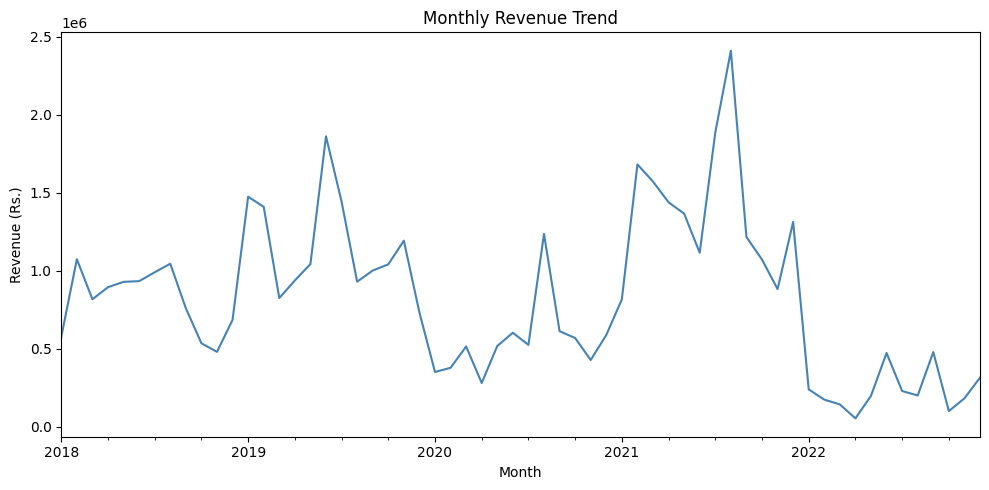

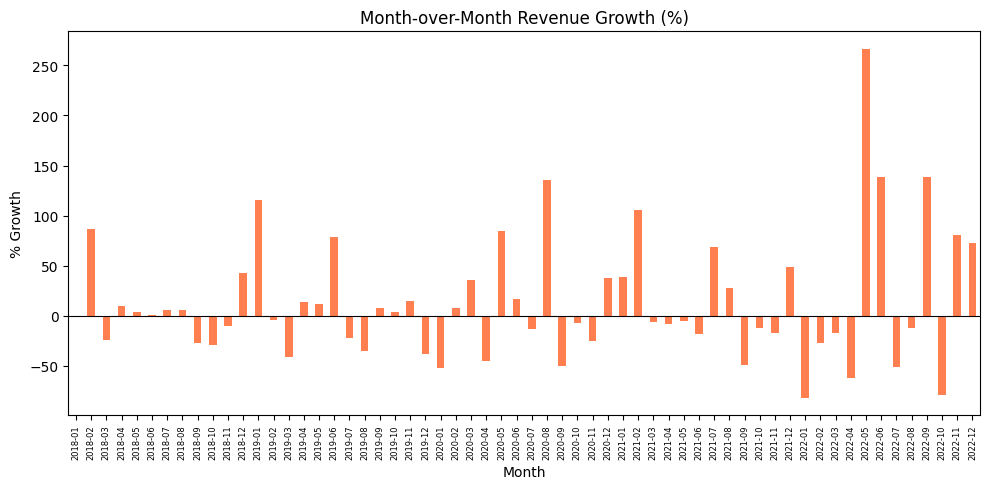

In [6]:
fig, ax1 = plt.subplots()
monthly_rev.plot(ax=ax1, color='steelblue', label='Monthly Revenue')
ax1.set_ylabel('Revenue (Rs.)')
ax1.set_xlabel('Month')
ax1.set_title('Monthly Revenue Trend')
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150)
plt.show()

plt.figure()
monthly_growth.plot(kind='bar', color='coral')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Month-over-Month Revenue Growth (%)')
plt.ylabel('% Growth')
plt.xlabel('Month')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('mom_growth.png', dpi=150)
plt.show()

In [7]:
# --- FY-over-FY revenue growth ---
fy_rev = df.groupby('F.Y')['Amount'].sum().sort_index()
fy_growth = fy_rev.pct_change() * 100

fy_growth_df = pd.DataFrame({
    'Revenue': fy_rev,
    'FY_Growth_%': fy_growth.round(2)
})
fy_growth_df.to_csv('fy_revenue_growth.csv')
fy_growth_df

,Revenue,FY_Growth_%
F.Y,,
2018-2019,31869038.08,NaN
2019-2020,30004315.90,-5.85
2020-2021,14622889.49,-51.26
2021-2022,45182591.58,208.99
2022-2023,1963737.76,-95.65


Revenue by FY and category:


/tmp/ipykernel_6365/2490597901.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fy_cat_growth = fy_cat_rev.pct_change() * 100


TYPE OF PRODUCT,ACCESSORY,MOBILE,TABLET
F.Y,,,
2018-2019,1533631.66,29385067.48,950338.94
2019-2020,1700433.62,27365497.48,938384.80
2020-2021,487977.16,13577782.69,557129.64
2021-2022,260534.84,44840810.96,81245.78
2022-2023,1516916.66,NaN,446821.10



FY-over-FY % growth by category:


TYPE OF PRODUCT,ACCESSORY,MOBILE,TABLET
F.Y,,,
2018-2019,NaN,NaN,NaN
2019-2020,10.88,-6.87,-1.26
2020-2021,-71.30,-50.38,-40.63
2021-2022,-46.61,230.25,-85.42
2022-2023,482.23,0.00,449.96


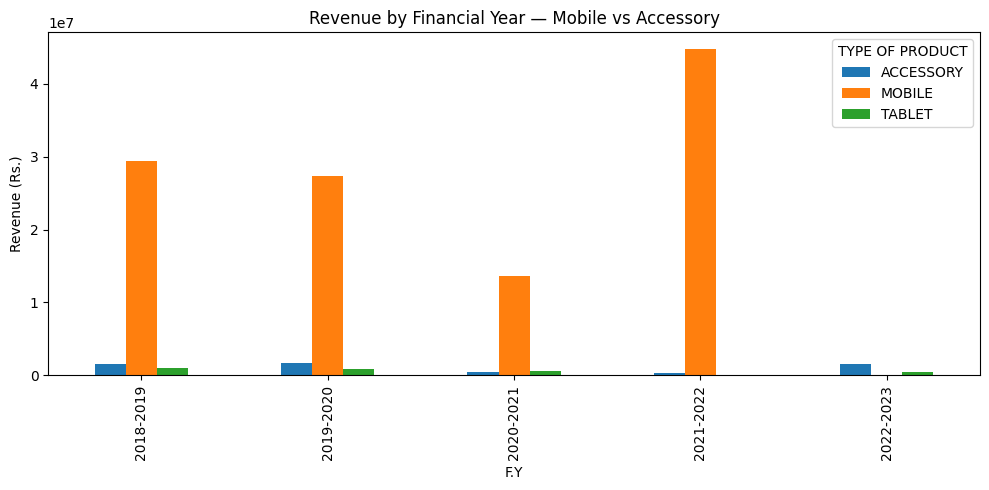

In [8]:
# --- FY-over-FY growth by product type (Mobile vs Accessory) ---
fy_cat_rev = df.pivot_table(index='F.Y', columns='TYPE OF PRODUCT', values='Amount', aggfunc='sum').sort_index()
fy_cat_growth = fy_cat_rev.pct_change() * 100

fy_cat_growth.to_csv('fy_growth_by_category.csv')
print("Revenue by FY and category:")
display(fy_cat_rev)
print()
print("FY-over-FY % growth by category:")
display(fy_cat_growth.round(2))

fy_cat_rev.plot(kind='bar')
plt.title('Revenue by Financial Year — Mobile vs Accessory')
plt.ylabel('Revenue (Rs.)')
plt.tight_layout()
plt.savefig('fy_revenue_by_category.png', dpi=150)
plt.show()

**Note:** FY2018-19 and the final FY in your data will show `NaN` for growth (no prior period to compare). This is expected, not an error. Also keep your documented context in mind when reading these numbers — four zero-sales months from COVID lockdowns and phone sales ceasing after March 2022 will show up here as sharp dips/drops; that's real, not a data issue.

## 5. Correlation Analysis

Two parts:
- **Numeric correlation** between `Quantity` and `Amount` — flagged as limited, since `Quantity` is 1 in ~99% of rows (near-zero variance), so this correlation is expected to be weak/uninformative on its own.
- **Categorical association (Cramér's V)** between `TYPE OF PRODUCT`, `PAYMENT TYPE`, `QUARTER`, and `TYPE OF ACCESSORY/MOBILE` — this is the more meaningful "correlation-style" analysis for this dataset, since most of your variables are categorical rather than numeric.

In [9]:
# --- Numeric correlation ---
numeric_corr = df[['Quantity', 'Amount']].corr()
print("Numeric correlation (Quantity vs Amount):")
print(numeric_corr.round(3))
print()
print(f"Quantity value counts (top 3):")
print(df['Quantity'].value_counts(normalize=True).round(3).head(3))

Numeric correlation (Quantity vs Amount):
          Quantity  Amount
Quantity     1.000   0.098
Amount       0.098   1.000

Quantity value counts (top 3):
Quantity
1    0.989
2    0.004
4    0.002
Name: proportion, dtype: float64


In [10]:
# --- Cramer's V for categorical association ---
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = ['TYPE OF PRODUCT', 'PAYMENT TYPE', 'QUARTER', 'TYPE OF ACCESSORY/MOBILE']
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramers_matrix.loc[c1, c2] = 1.0
        else:
            cramers_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

cramers_matrix = cramers_matrix.astype(float).round(3)
cramers_matrix.to_csv('categorical_association_cramers_v.csv')
cramers_matrix

,TYPE OF PRODUCT,PAYMENT TYPE,QUARTER,TYPE OF ACCESSORY/MOBILE
TYPE OF PRODUCT,1.000,0.090,0.068,0.999
PAYMENT TYPE,0.090,1.000,0.013,0.146
QUARTER,0.068,0.013,1.000,0.112
TYPE OF ACCESSORY/MOBILE,0.999,0.146,0.112,1.000


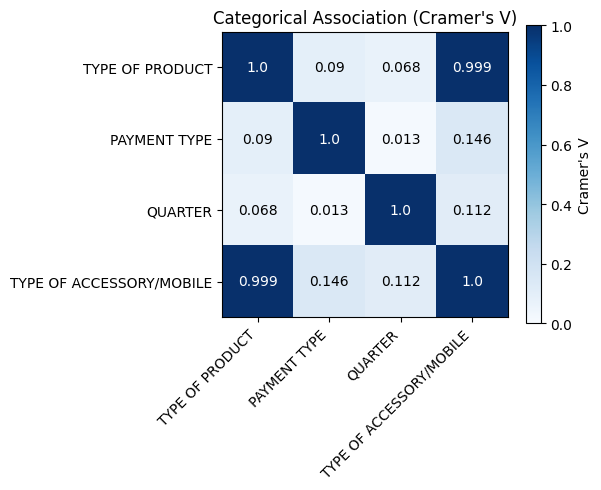

In [11]:
plt.figure(figsize=(6,5))
plt.imshow(cramers_matrix, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label="Cramer's V")
plt.xticks(range(len(cat_cols)), cat_cols, rotation=45, ha='right')
plt.yticks(range(len(cat_cols)), cat_cols)
for i in range(len(cat_cols)):
    for j in range(len(cat_cols)):
        plt.text(j, i, cramers_matrix.iloc[i,j], ha='center', va='center',
                  color='white' if cramers_matrix.iloc[i,j] > 0.5 else 'black')
plt.title("Categorical Association (Cramer's V)")
plt.tight_layout()
plt.savefig('cramers_v_heatmap.png', dpi=150)
plt.show()

**Reading Cramér's V:** ranges 0 to 1. Roughly: <0.1 = negligible association, 0.1–0.3 = weak, 0.3–0.5 = moderate, >0.5 = strong. This tells you, for example, whether payment method tends to differ by product type, or whether product type varies meaningfully by quarter (a proxy for seasonality since there's no explicit promotion column in this dataset).

## 6. Download Outputs

Run the cell below to download everything as a zip — bring these files back and we'll go through them together to decide what (if anything) goes into Section 3 of the report.

In [12]:
import shutil
from google.colab import files as gfiles

output_files = [
    'monthly_revenue_growth.csv',
    'fy_revenue_growth.csv',
    'fy_growth_by_category.csv',
    'categorical_association_cramers_v.csv',
    'monthly_revenue_trend.png',
    'mom_growth.png',
    'fy_revenue_by_category.png',
    'cramers_v_heatmap.png'
]

shutil.make_archive('growth_correlation_outputs', 'zip', '.', )
# Zip only the relevant files
import zipfile
with zipfile.ZipFile('growth_correlation_outputs.zip', 'w') as zf:
    for f in output_files:
        zf.write(f)

gfiles.download('growth_correlation_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>